In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load Excel file
df = pd.read_excel(r"C:\Users\aman4645\OneDrive\Documents\New folder\customer_shopping_da.xlsx")

# Display first few rows to confirm it loaded correctly
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon


In [ ]:
# Display last few rows to confirm it loaded correctly
df.tail()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,2022-09-21,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,2021-09-22,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,2021-03-28,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,2021-03-16,Istinye Park
99456,I232867,C273973,Female,36,Souvenir,3,35.19,Credit Card,2022-10-15,Mall of Istanbul


In [ ]:
# Check for missing values in the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  str           
 1   customer_id     99457 non-null  str           
 2   gender          99457 non-null  str           
 3   age             99457 non-null  int64         
 4   category        99457 non-null  str           
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  str           
 8   invoice_date    99457 non-null  datetime64[us]
 9   shopping_mall   99457 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 7.6 MB


In [ ]:
# Check for missing values in the DataFrame
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [ ]:
# check for duplicate rows if any
df.duplicated().sum()


np.int64(0)

In [ ]:
# 6. Fix column names (remove extra spaces, standardize case)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns.tolist())

['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity', 'price', 'payment_method', 'invoice_date', 'shopping_mall']


In [ ]:
# 9. Checking for inconsistent text values (e.g. "Female"/"female"/"F")
for col in ["gender", "category", "payment_method", "shopping_mall"]:
    print(col, df[col].unique())

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
category <StringArray>
[       'Clothing',           'Shoes',           'Books',       'Cosmetics',
 'Food & Beverage',            'Toys',      'Technology',        'Souvenir']
Length: 8, dtype: str
payment_method <StringArray>
['Credit Card', 'Debit Card', 'Cash']
Length: 3, dtype: str
shopping_mall <StringArray>
[           'Kanyon',    'Forum Istanbul',         'Metrocity',
      'Metropol AVM',      'Istinye Park',  'Mall of Istanbul',
 'Emaar Square Mall',       'Cevahir AVM',    'Viaport Outlet',
      'Zorlu Center']
Length: 10, dtype: str


In [ ]:
# 10. Check for outliers/invalid numbers
print(df[["age", "quantity", "price"]].describe())

                age      quantity         price
count  99457.000000  99457.000000  99457.000000
mean      43.427089      3.003429    689.256321
std       14.990054      1.413025    941.184567
min       18.000000      1.000000      5.230000
25%       30.000000      2.000000     45.450000
50%       43.000000      3.000000    203.300000
75%       56.000000      4.000000   1200.320000
max       69.000000      5.000000   5250.000000


In [ ]:
# Round all float columns to 2 decimal places
float_cols = df.select_dtypes(include="float64").columns
df[float_cols] = df[float_cols].round(2)

df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon


In [ ]:
# 10. Check for outliers/invalid numbers
pd.set_option('display.float_format', '{:.2f}'.format)
print(df[["age", "quantity", "price"]].describe())

           age  quantity    price
count 99457.00  99457.00 99457.00
mean     43.43      3.00   689.26
std      14.99      1.41   941.18
min      18.00      1.00     5.23
25%      30.00      2.00    45.45
50%      43.00      3.00   203.30
75%      56.00      4.00  1200.32
max      69.00      5.00  5250.00


In [ ]:
# Capitalizing the first letter of every word.
str_cols = df.select_dtypes(include="object").columns

for col in str_cols:
    df[col] = df[col].astype(str).str.title()

df.head()

C:\Users\aman4645\AppData\Local\Temp\ipykernel_30884\504605073.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol Avm
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon


In [ ]:
# Checking unique values in the "shopping_mall" and "category" columns.
df["shopping_mall"].unique()
df["category"].unique()

<StringArray>
[       'Clothing',           'Shoes',           'Books',       'Cosmetics',
 'Food & Beverage',            'Toys',      'Technology',        'Souvenir']
Length: 8, dtype: str

In [ ]:
# clean, complete trim + cleanup for all string columns.
str_cols = df.select_dtypes(include="object").columns

for col in str_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()                      # remove leading/trailing spaces
        .str.replace(r"\s+", " ", regex=True)  # collapse multiple spaces into one
                
    )

df.head()

C:\Users\aman4645\AppData\Local\Temp\ipykernel_30884\1844444518.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol Avm
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon


In [ ]:
# Verifying the unique values in all string columns after cleaning
for col in str_cols:
    print(col, df[col].unique())

invoice_no <StringArray>
['I138884', 'I317333', 'I127801', 'I173702', 'I337046', 'I227836', 'I121056',
 'I293112', 'I293455', 'I326945',
 ...
 'I281214', 'I332105', 'I134399', 'I170504', 'I675411', 'I219422', 'I325143',
 'I824010', 'I702964', 'I232867']
Length: 99457, dtype: str
customer_id <StringArray>
['C241288', 'C111565', 'C266599', 'C988172', 'C189076', 'C657758', 'C151197',
 'C176086', 'C159642', 'C283361',
 ...
 'C288090', 'C231387', 'C953724', 'C226974', 'C513603', 'C441542', 'C569580',
 'C103292', 'C800631', 'C273973']
Length: 99457, dtype: str
gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
category <StringArray>
[       'Clothing',           'Shoes',           'Books',       'Cosmetics',
 'Food & Beverage',            'Toys',      'Technology',        'Souvenir']
Length: 8, dtype: str
payment_method <StringArray>
['Credit Card', 'Debit Card', 'Cash']
Length: 3, dtype: str
shopping_mall <StringArray>
[           'Kanyon',    'Forum Istanbul',         'Metrocity

In [ ]:
#Before Saving The Cleaned Data to a New Excel file, let's check the first few rows of the cleaned DataFrame to ensure everything looks good.
df.describe()
df.isnull().sum()
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  str           
 1   customer_id     99457 non-null  str           
 2   gender          99457 non-null  str           
 3   age             99457 non-null  int64         
 4   category        99457 non-null  str           
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  str           
 8   invoice_date    99457 non-null  datetime64[us]
 9   shopping_mall   99457 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 7.6 MB


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol Avm
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon


In [ ]:
#Saving the cleaned DataFrame to a new Excel file
df.to_excel(r"C:\Users\aman4645\OneDrive\Documents\New folder\cleaned_customer_shopping_data.xlsx", index=False)

In [ ]:
# Adding a new column "total_sales" to the DataFrame, which is the product of "price" and "quantity".
df["total_sales"] = df["price"] * df["quantity"]
df[["price", "quantity", "total_sales"]].head()

df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_sales
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol Avm,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,242.40


In [ ]:
# Adding a new column "month" to the DataFrame, which contains the month name of each invoice date.
df["month"] = df["invoice_date"].dt.month_name()
df[["invoice_date", "month"]].head()

df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,total_sales,month
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,7502.00,August
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,5401.53,December
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,300.08,November
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol Avm,15004.25,May
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,242.40,October


In [ ]:
# Adding a new column "year" to the DataFrame, which contains the year of each invoice date.
df["year"] = df["invoice_date"].dt.year
df[["invoice_date", "year"]].head()

,invoice_date,year
0,2022-08-05,2022
1,2021-12-12,2021
2,2021-11-09,2021
3,2021-05-16,2021
4,2021-10-24,2021


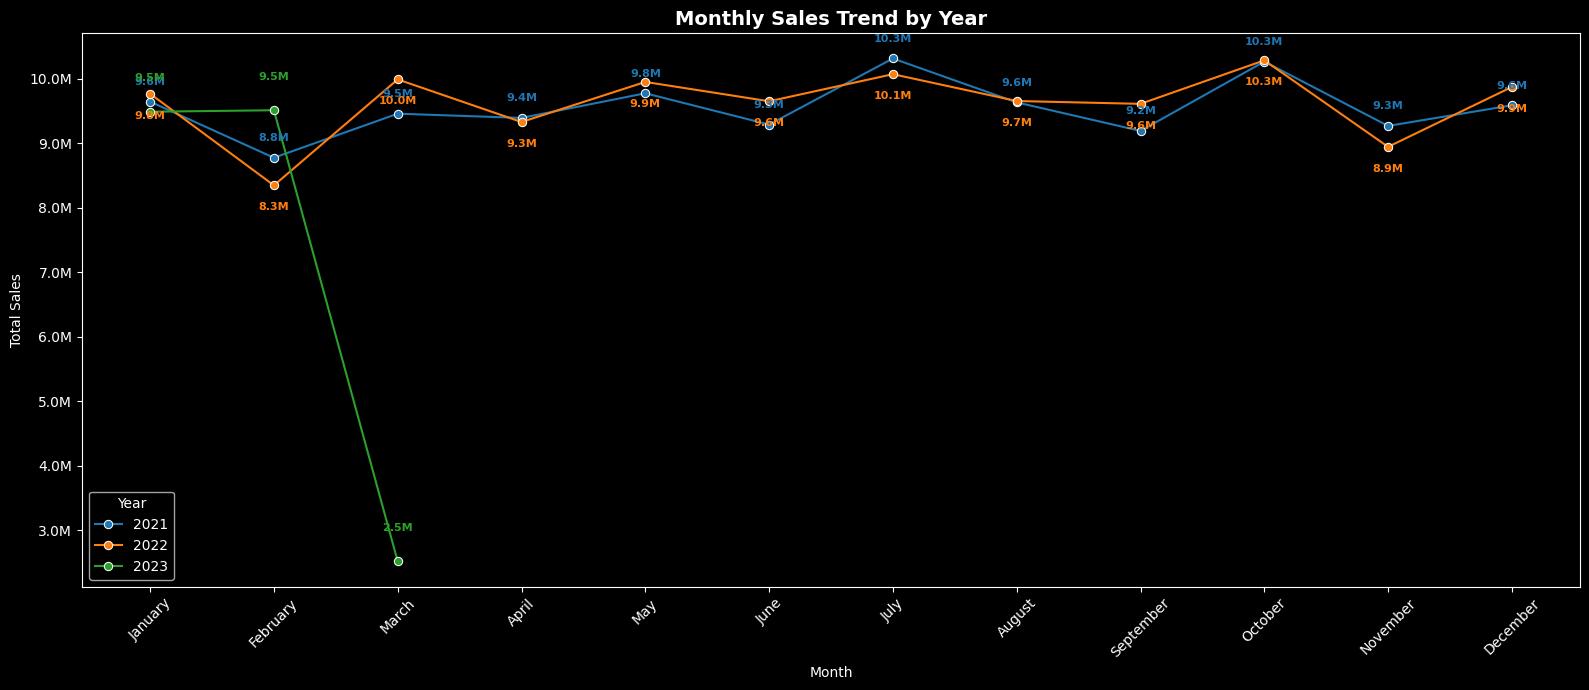

In [ ]:
# Creating a chart to visualize the monthly sales trend by year using a dark background theme and bold, offset labels for each year.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Dark background theme
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(16,7))
sns.lineplot(data=monthly_data, x="month", y="total_sales", hue="year", marker="o", palette="tab10", ax=ax)

# Format Y-axis as "10M", "9M", etc.
def millions_formatter(x, pos):
    return f'{x/1_000_000:.1f}M'
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))

# Bold, offset labels per year to avoid overlap
offsets = {0: 12, 1: -18, 2: 22}

for i, line in enumerate(ax.lines):
    x_data = line.get_xdata()
    y_data = line.get_ydata()
    offset = offsets.get(i, 10)
    for x, y in zip(x_data, y_data):
        ax.annotate(f'{y/1_000_000:.1f}M', (x, y),
                    textcoords="offset points", xytext=(0, offset),
                    fontsize=8, fontweight='bold', ha='center',
                    color=line.get_color())

# Title, labels, legend all auto-adapt to dark background via plt.style
ax.set_title("Monthly Sales Trend by Year", fontsize=14, fontweight='bold', color='white')
ax.set_xlabel("Month", color='white')
ax.set_ylabel("Total Sales", color='white')
plt.xticks(rotation=45, color='white')
plt.yticks(color='white')
ax.grid(False)

legend = ax.legend(title="Year")
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')

plt.tight_layout()
plt.show()

#

In [ ]:
# Adding a new column "quarter" to the DataFrame, which contains the quarter of each invoice date.
df["quarter"] = "Q" + df["invoice_date"].dt.quarter.astype(str)
df[["invoice_date", "quarter"]].head()

,invoice_date,quarter
0,2022-08-05,Q3
1,2021-12-12,Q4
2,2021-11-09,Q4
3,2021-05-16,Q2
4,2021-10-24,Q4


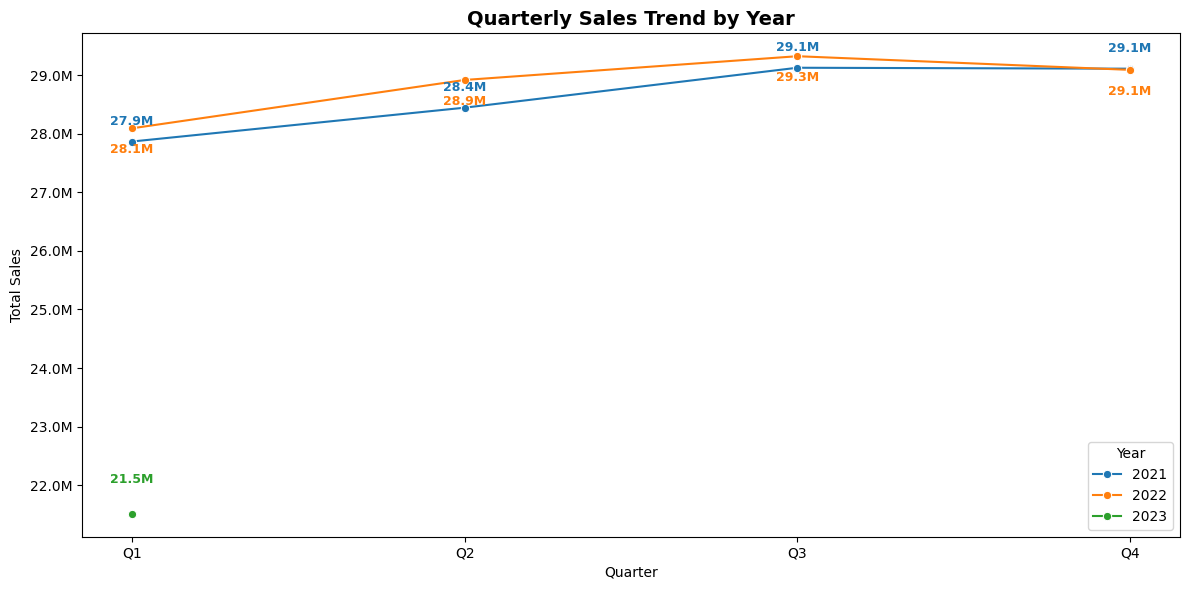

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Switch to white/light background
plt.style.use('default')  # instead of 'dark_background'

fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(data=quarterly_data, x="quarter", y="total_sales", hue="year", marker="o", palette="tab10", ax=ax)

# Format Y-axis as "10M", "9M", etc.
def millions_formatter(x, pos):
    return f'{x/1_000_000:.1f}M'
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))

# Bold, offset labels per year
offsets = {0: 12, 1: -18, 2: 22}

for i, line in enumerate(ax.lines):
    x_data = line.get_xdata()
    y_data = line.get_ydata()
    offset = offsets.get(i, 10)
    for x, y in zip(x_data, y_data):
        ax.annotate(f'{y/1_000_000:.1f}M', (x, y),
                    textcoords="offset points", xytext=(0, offset),
                    fontsize=9, fontweight='bold', ha='center',
                    color=line.get_color())

ax.set_title("Quarterly Sales Trend by Year", fontsize=14, fontweight='bold', color='black')
ax.set_xlabel("Quarter", color='black')
ax.set_ylabel("Total Sales", color='black')
plt.xticks(color='black')
plt.yticks(color='black')
ax.grid(False)

legend = ax.legend(title="Year")
plt.setp(legend.get_texts(), color='black')
plt.setp(legend.get_title(), color='black')

plt.tight_layout()
plt.show()

In [ ]:
# Creating a new DataFrame with unique customer records by dropping duplicates based on "customer_id".
customer_df = df.drop_duplicates(subset="customer_id").copy()

print(customer_df.shape)

(99457, 14)


In [ ]:
# Displaying the first few rows of the customer DataFrame to verify its structure and contents.
print(customer_df[["customer_id", "age", "gender"]].head())

  customer_id  age  gender
0     C241288   28  Female
1     C111565   21    Male
2     C266599   20    Male
3     C988172   66  Female
4     C189076   53  Female


In [ ]:
# Gender distribution of unique customers.
print(customer_df["gender"].value_counts())

gender
Female    59482
Male      39975
Name: count, dtype: int64


In [ ]:
# Creating age groups for customers using pd.cut() to categorize them into defined age ranges.
bins = [0, 25, 35, 45, 55, 100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

customer_df["Age_Group"] = pd.cut(
    customer_df["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


In [ ]:
# Displaying the count of customers in each age group.
print(customer_df["Age_Group"].value_counts().sort_index())

Age_Group
18-25    15359
26-35    19059
36-45    19436
46-55    19016
56+      26587
Name: count, dtype: int64


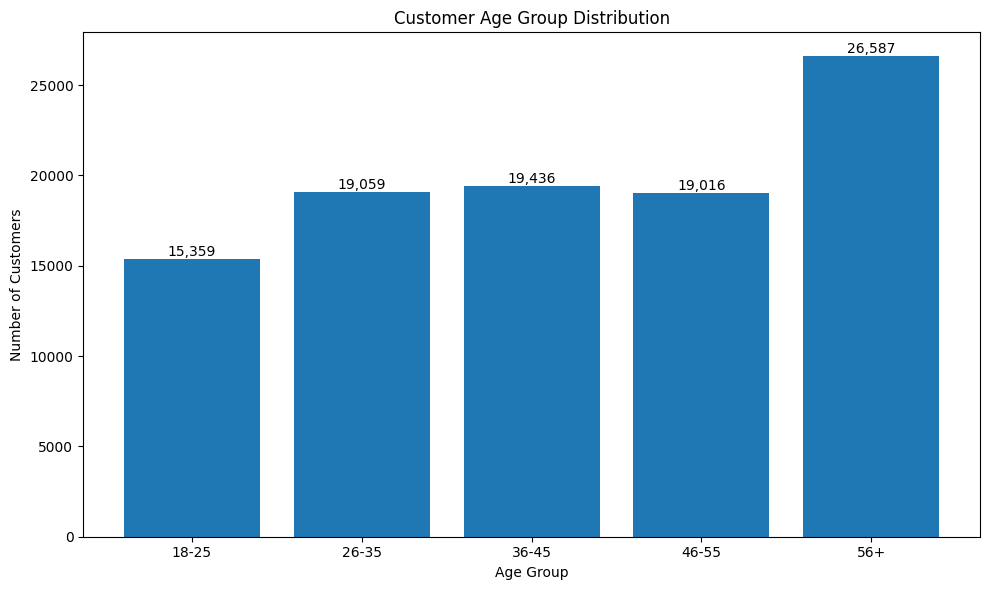

In [ ]:
# Creating a bar chart to visualize the distribution of customers across different age groups.
import matplotlib.pyplot as plt

age_count = customer_df["Age_Group"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

bars = plt.bar(age_count.index, age_count.values)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

# Add numbers on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Counting the number of unique customers by gender.
gender_count = customer_df["gender"].value_counts()

print(gender_count)

gender
Female    59482
Male      39975
Name: count, dtype: int64


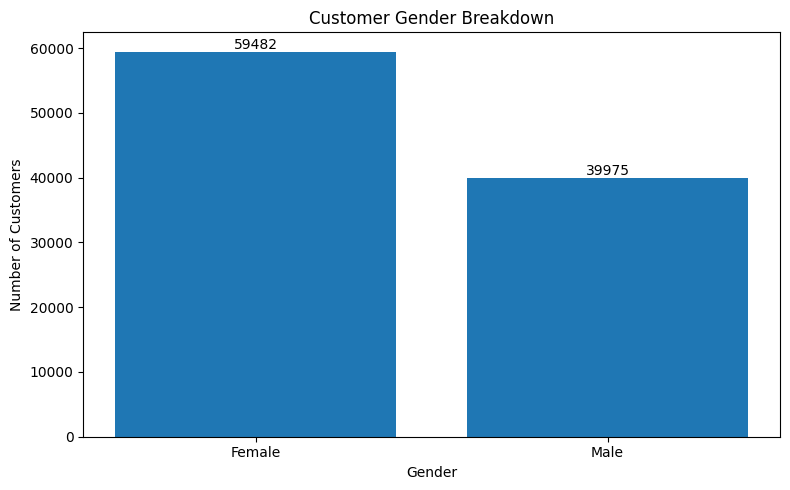

In [ ]:
# Creating a bar chart to visualize the distribution of customers by gender.
import matplotlib.pyplot as plt

gender_count = customer_df["gender"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    gender_count.index,
    gender_count.values
)

plt.title("Customer Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Calculating the percentage of customers by gender.
gender_percentage = (
    customer_df["gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(gender_percentage)

#insights : Female customers represent 59.81% of the customer base, while male customers represent 40.19%.

gender
Female   59.81
Male     40.19
Name: proportion, dtype: float64


In [ ]:
# Creating a cross-tabulation to analyze the relationship between age groups and gender.
age_gender = pd.crosstab(
    customer_df["Age_Group"],
    customer_df["gender"]
)

print(age_gender)


gender     Female   Male
Age_Group               
18-25        9082   6277
26-35       11410   7649
36-45       11762   7674
46-55       11334   7682
56+         15894  10693


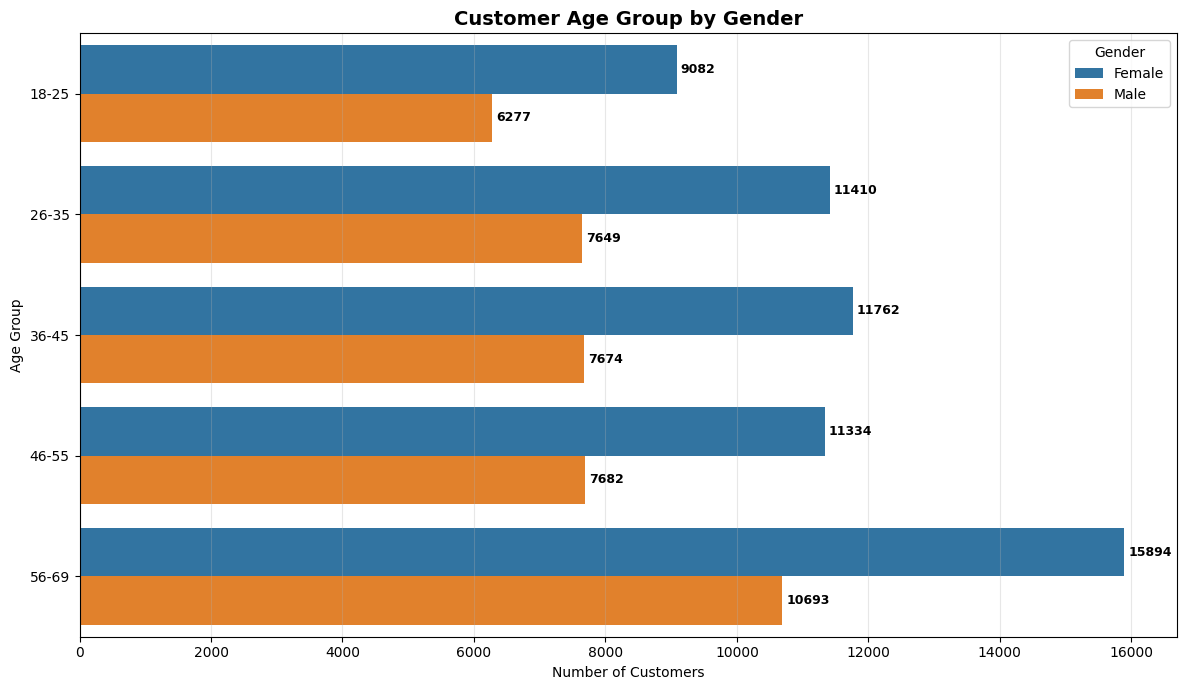

In [ ]:
# Creating a bar chart to visualize the distribution of customers by age.
import matplotlib.pyplot as plt
import seaborn as sns

# If you don't already have an age_group column, create bins first
bins = [17, 25, 35, 45, 55, 70]
labels = ["18-25", "26-35", "36-45", "46-55", "56-69"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

# Count customers by age_group and gender
age_gender_counts = df.groupby(["age_group", "gender"], observed=True).size().reset_index(name="count")

plt.style.use('default')
fig, ax = plt.subplots(figsize=(12,7))

sns.barplot(data=age_gender_counts, y="age_group", x="count", hue="gender", palette="tab10", ax=ax)

# Add value labels on each horizontal bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight='bold', padding=3)

ax.set_title("Customer Age Group by Gender", fontsize=14, fontweight='bold', color='black')
ax.set_xlabel("Number of Customers", color='black')
ax.set_ylabel("Age Group", color='black')
ax.grid(True, axis='x', alpha=0.3)

legend = ax.legend(title="Gender")
plt.setp(legend.get_texts(), color='black')
plt.setp(legend.get_title(), color='black')

plt.tight_layout()
plt.show()

C:\Users\aman4645\AppData\Local\Temp\ipykernel_30884\1429960648.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_revenue, y="category", x="total_sales", palette="viridis", ax=ax)


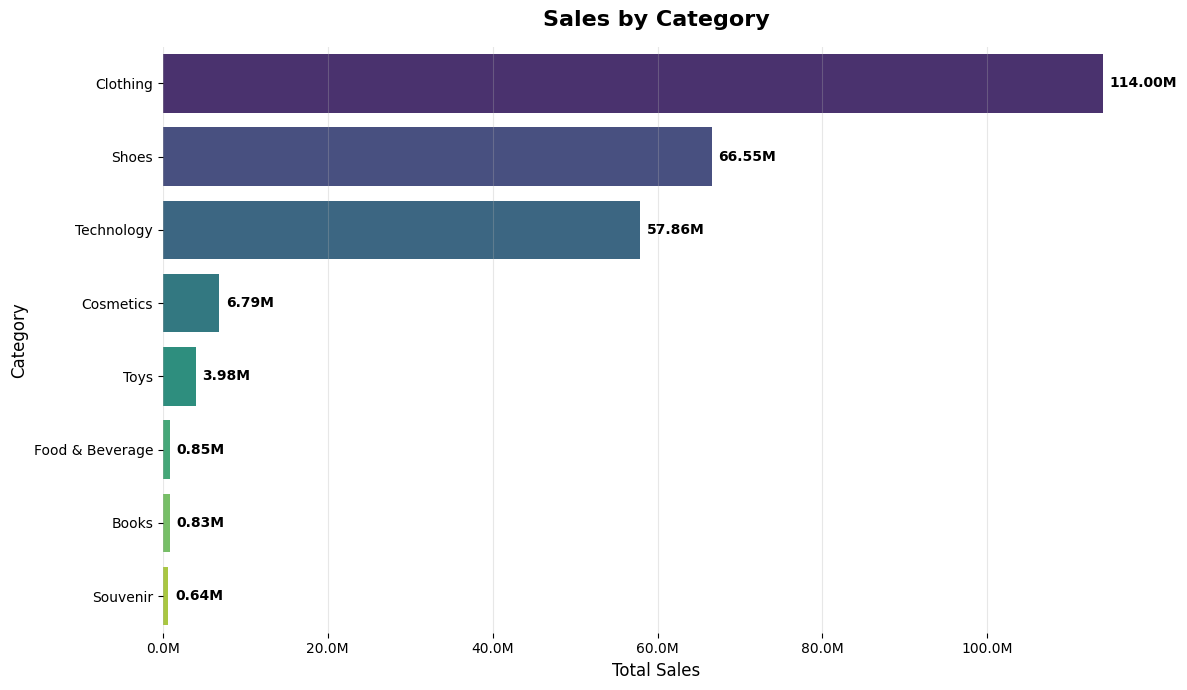

In [ ]:
# Top 10 product categories Analysis by Sales.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Revenue by category
category_revenue = df.groupby("category")["total_sales"].sum().sort_values(ascending=False).reset_index()

plt.style.use('default')
fig, ax = plt.subplots(figsize=(12,7))

sns.barplot(data=category_revenue, y="category", x="total_sales", palette="viridis", ax=ax)

# Format X-axis as millions
def millions_formatter(x, pos):
    return f'{x/1_000_000:.1f}M'
ax.xaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x/1_000_000:.2f}M', fontsize=10, fontweight='bold', padding=5, color='black')

ax.set_title("Sales by Category", fontsize=16, fontweight='bold', color='black', pad=15)
ax.set_xlabel("Total Sales", fontsize=12, color='black')
ax.set_ylabel("Category", fontsize=12, color='black')
ax.grid(True, axis='x', alpha=0.3)

# Presentation-level polish
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

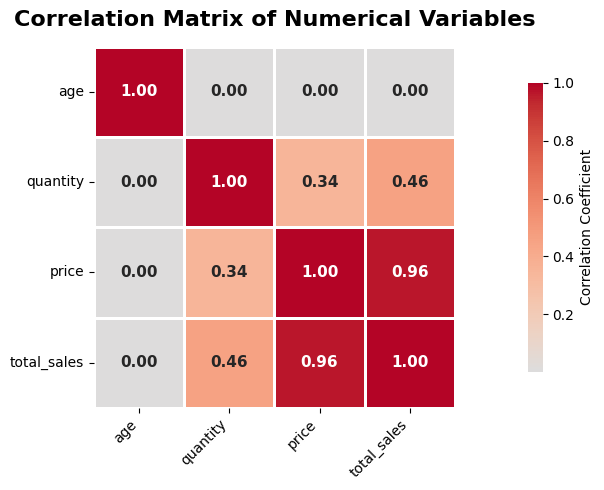

In [ ]:
# Creating a correlation matrix heatmap for numerical variables in the dataset.
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numeric_cols = ["age", "quantity", "price", "total_sales"]
corr_matrix = df[numeric_cols].corr()

plt.style.use('default')
fig, ax = plt.subplots(figsize=(15,5))

sns.heatmap(
    corr_matrix,
    annot=True,           # show correlation values
    fmt=".2f",             # 2 decimal places
    cmap="coolwarm",       # attractive diverging color scale (blue-red)
    center=0,               # 0 correlation = neutral color
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    annot_kws={"fontsize": 11, "fontweight": "bold"},
    ax=ax
)

ax.set_title("Correlation Matrix of Numerical Variables", fontsize=16, fontweight='bold', color='black', pad=15)
plt.xticks(rotation=45, ha='right', color='black')
plt.yticks(rotation=0, color='black')

plt.tight_layout()
plt.show()


C:\Users\aman4645\AppData\Local\Temp\ipykernel_30884\2030921597.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_revenue, x="payment_method", y="total_sales", palette="magma", ax=ax)


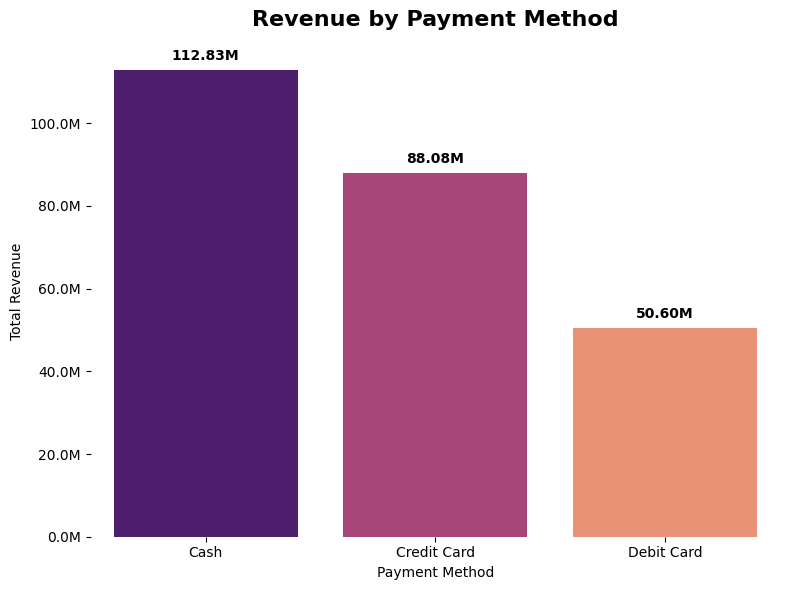

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

payment_revenue = df.groupby("payment_method")["total_sales"].sum().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(data=payment_revenue, x="payment_method", y="total_sales", palette="magma", ax=ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x/1_000_000:.2f}M', fontsize=10, fontweight='bold', padding=5)
ax.set_title("Revenue by Payment Method", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Payment Method")
ax.set_ylabel("Total Revenue")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
# Summarizing the top category by revenue and the most used payment method based on total sales.

print("Top category by revenue:", category_revenue.iloc[0]["category"], "-", f"{category_revenue.iloc[0]['total_sales']/1e6:.2f}M")
print("Most used payment method:", payment_revenue.iloc[0]["payment_method"], "-", f"{payment_revenue.iloc[0]['total_sales']/1e6:.2f}M")

Top category by revenue: Clothing - 114.00M
Most used payment method: Cash - 112.83M


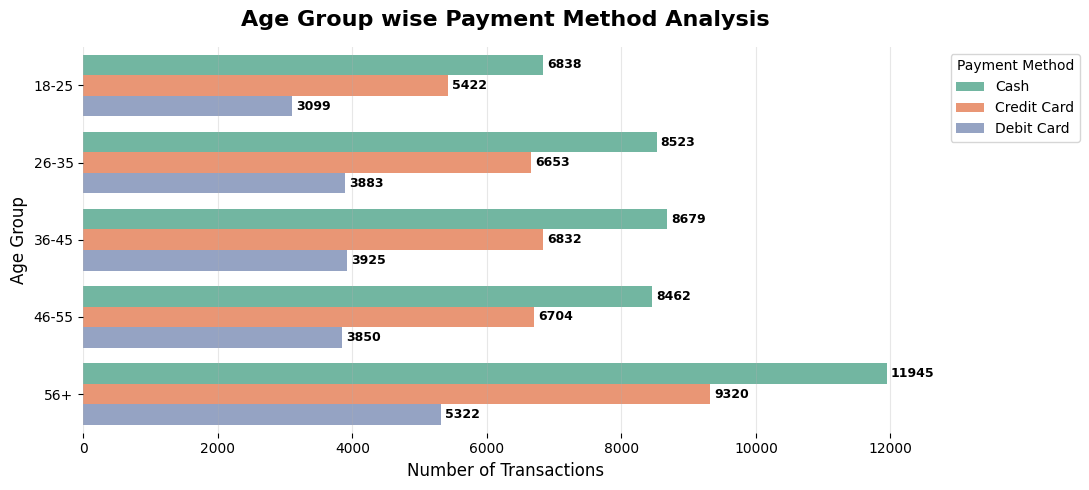

In [ ]:
# Age Group wise Payment Method Analysis.
import matplotlib.pyplot as plt
import seaborn as sns

# Age group already created earlier; recreate if needed
bins = [17, 25, 35, 45, 55, 70]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

# Count by age_group and payment_method
age_payment = df.groupby(["age_group", "payment_method"], observed=True).size().reset_index(name="count")

plt.style.use('default')
fig, ax = plt.subplots(figsize=(11,5))

sns.barplot(data=age_payment, y="age_group", x="count", hue="payment_method", palette="Set2", ax=ax)

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight='bold', padding=3)

ax.set_title("Age Group wise Payment Method Analysis", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Number of Transactions", fontsize=12)
ax.set_ylabel("Age Group", fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

legend = ax.legend(title="Payment Method", bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
# Calculating the percentage of transactions by payment method.
payment_pct = df["payment_method"].value_counts(normalize=True) * 100
payment_pct = payment_pct.round(2)
print(payment_pct)

payment_method
Cash          44.69
Credit Card   35.12
Debit Card    20.19
Name: proportion, dtype: float64


## Conclusion & Recommendations

1. Age doesn't affect spending - Since age showed no link to purchase behavior, marketing doesn't need to target specific age groups — focus budget elsewhere instead.

2. Cash is the most-used payment method: Debit Card is the least.** This is worth investigating further — the business could consider incentives (e.g. discounts) to encourage more Card usage, though this would need testing since discount impact isn't part of this dataset.

3. Female customers out number male customers in every age group - A campaign or product mix aimed at male shoppers could help grow this underrepresented segment.

# (Note: 2023 data only covers Jan–Mar, so it's not compared against full-year totals.)

In [ ]:
# all charts wise Analysis.
#Sales Growth % :
Sales_Growth = df.groupby("year")["total_sales"].sum().pct_change().mul(100).round(2)
print(Sales_Growth)

#Note: (2023 have only 1st quarter data,so the sales growth for 2023 will not be accurate and should be interpreted with caution.)


year
2021      NaN
2022     0.76
2023   -81.37
Name: total_sales, dtype: float64


In [ ]:
#Female and male Purchase % Analysis:
Female_Purchase = df[df['gender'] == 'Female']['total_sales'].sum()
Male_Purchase = df[df['gender'] == 'Male']['total_sales'].sum()
Total_Purchase = Female_Purchase + Male_Purchase
male_percentage = (Male_Purchase / Total_Purchase) * 100
female_percentage = (Female_Purchase / Total_Purchase) * 100

print(f"Female Purchase %: {female_percentage:.2f}%")
print(f"Male Purchase %: {male_percentage:.2f}%")



Female Purchase %: 59.72%
Male Purchase %: 40.28%


In [ ]:
# Category wise Purchase % Analysis:
Category_Purchases = df.groupby('category')['total_sales'].sum()
Total_Purchases = Category_Purchases.sum()
Category_Percentages = (Category_Purchases / Total_Purchases) * 100
print(Category_Percentages.round(2))

# Category wise Sales Analysis:
df[["category", "total_sales"]].groupby("category").sum().sort_values(by="total_sales", ascending=False)
# Where Clothing is the top category by Total Sales(114.00M) and the least category is "Souvenir" by Total Sales(0.64M).

category
Books              0.33
Clothing          45.33
Cosmetics          2.70
Food & Beverage    0.34
Shoes             26.46
Souvenir           0.25
Technology        23.01
Toys               1.58
Name: total_sales, dtype: float64


,total_sales
category,
Clothing,113996791.04
Shoes,66553451.47
Technology,57862350.00
Cosmetics,6792862.90
Toys,3980426.24
Food & Beverage,849535.05
Books,834552.90
Souvenir,635824.65


# Category wise Purchase % Analysis
Where Clothing  has the highest purchase with  (45.33%) percentage, followed by Electronics and Home & Kitchen. This indicates that customers are more inclined to spend on clothing and accessories compared to other categories.
# Category Wise Sales Analysis
Where Clothing is the top category by Total Sales(114.00M) and the least category is "Souvenir" by Total Sales(0.64M).

In [ ]:
# Gender wise Purchase Analysis:
df.groupby('gender')['total_sales'].sum()
# Total Sales:
print(f"Total Sales: {df['total_sales'].sum():.2f}")

Total Sales: 251505794.25


# Gender wise Sales Analysis
Where Female is the top gender by Total Sales(150.21) with Total market of Sale (59.72%). And Male with Total Sales(101.30M)  with Total market of Sale (40.28%).

 Where Total Sales : (251.51M)

In [ ]:
# Customer age group distribution Analysis:
age_group_distribution = customer_df["Age_Group"].value_counts().sort_index()
print(age_group_distribution)

# Percentage of customers in each age group:
age_group_percentages = (age_group_distribution / len(customer_df)) * 100
print(age_group_percentages)


Age_Group
18-25    15359
26-35    19059
36-45    19436
46-55    19016
56+      26587
Name: count, dtype: int64
Age_Group
18-25   15.44
26-35   19.16
36-45   19.54
46-55   19.12
56+     26.73
Name: count, dtype: float64


# Customer Age Group wise Count or % Analysis
Customer with Age Group 56+ Showing the Highest Number (26587) with (26.73%) Contribution to the total customer base. The least represented age group is 18-25 with only 15.44% of the total customers.

In [ ]:
# Payment method distribution Analysis:
Payment_method_distribution = df.groupby("payment_method")["total_sales"].sum()
print(Payment_method_distribution)

# Percentage of total sales by payment method:
Payment_method_percentage = (Payment_method_distribution / Payment_method_distribution.sum()) * 100
print(Payment_method_percentage)

# Payment method distribution Analysis:
# Where "Cash" is the most used payment method by Purchase (112.83M) with (44.86%) Distribution and the least used payment method is "Debit Card" by Purchase (50.60M) with (20.21%) Distribution.

payment_method
Cash          112832243.02
Credit Card    88077123.77
Debit Card     50596427.46
Name: total_sales, dtype: float64
payment_method
Cash          44.86
Credit Card   35.02
Debit Card    20.12
Name: total_sales, dtype: float64


# Payment method distribution Analysis
Where "Cash" is the most used payment method by Purchase (112.83M) with (44.86%) Distribution and the least used payment method is "Debit Card" by Purchase (50.60M) with (20.21%) Distribution.

## Correlation Insights

- **Age vs Quantity, Price, Total Sales (0.00):** Customer age has no effect on purchase behavior or spending.
- **Quantity vs Price (0.34):** Weak link — item price barely influences how many units customers buy.
- **Quantity vs Total Sales (0.46):** Moderate link — buying more units increases total sales, but not strongly.
- **Price vs Total Sales (0.96):** Very strong link — item price is the main driver of total revenue.

## Age Group wise Payment Method Analysis

Compares transaction counts by age group and payment method (Cash, Credit Card, Debit Card).

**Key Insights:**
- Cash is the top payment method across all age groups, followed by Credit Card, then Debit Card.
- 56+ age group has the highest transaction volume overall.
- 18-25 age group has the lowest transaction volume, especially for Debit Card.
- Payment method preference order stays the same across all ages — only volume changes.

C:\Users\aman4645\AppData\Local\Temp\ipykernel_30884\1083521953.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mall_sales, y="shopping_mall", x="total_sales", palette="viridis", order=mall_sales["shopping_mall"], ax=ax)


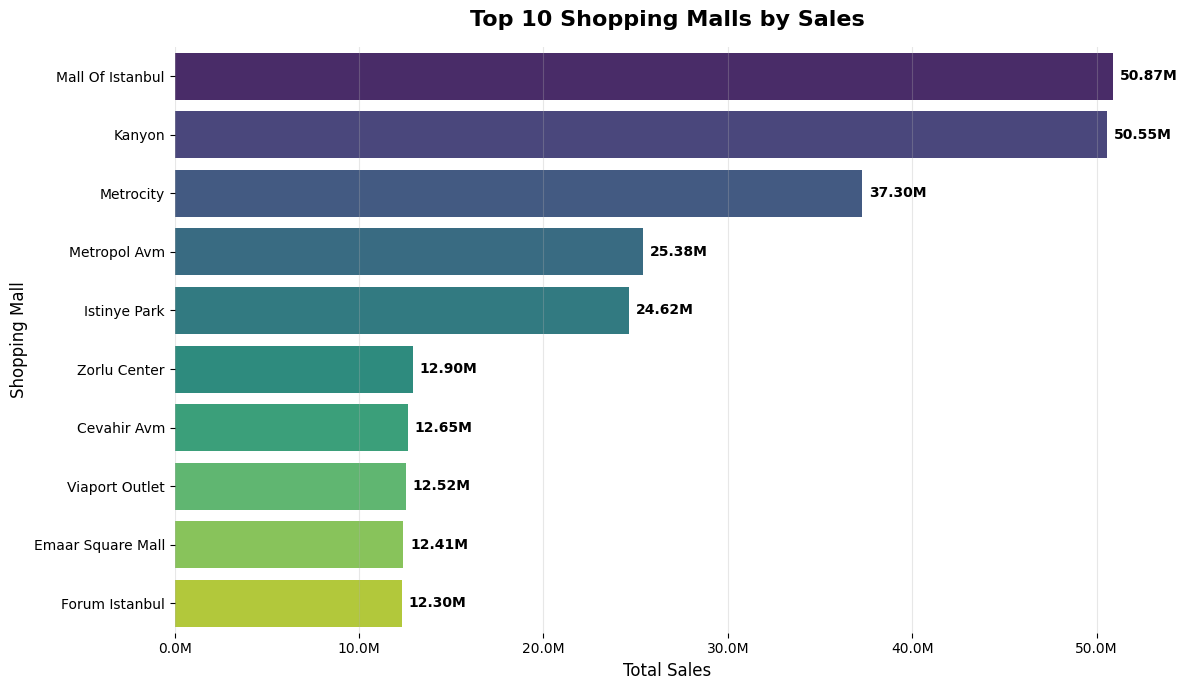

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Total sales by shopping mall, top 10 descending
mall_sales = df.groupby("shopping_mall")["total_sales"].sum().sort_values(ascending=False).head(10).reset_index()

plt.style.use('default')
fig, ax = plt.subplots(figsize=(12,7))

sns.barplot(data=mall_sales, y="shopping_mall", x="total_sales", palette="viridis", order=mall_sales["shopping_mall"], ax=ax)

# Format X-axis as millions
def millions_formatter(x, pos):
    return f'{x/1_000_000:.1f}M'
ax.xaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x/1_000_000:.2f}M', fontsize=10, fontweight='bold', padding=5)

ax.set_title("Top 10 Shopping Malls by Sales", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Total Sales", fontsize=12)
ax.set_ylabel("Shopping Mall", fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
# top 10 Shopping Malls By Sales Analysis:
top_10_malls = df.groupby("shopping_mall")["total_sales"].sum().nlargest(10)
print(top_10_malls)

# percentage of total sales by top 10 Shopping Malls:
top_10_malls_percentage = (top_10_malls / top_10_malls.sum()) * 100
print(top_10_malls_percentage)

shopping_mall
Mall Of Istanbul    50872481.68
Kanyon              50554231.10
Metrocity           37302787.33
Metropol Avm        25379913.19
Istinye Park        24618827.68
Zorlu Center        12901053.82
Cevahir Avm         12645138.20
Viaport Outlet      12521339.72
Emaar Square Mall   12406100.29
Forum Istanbul      12303921.24
Name: total_sales, dtype: float64
shopping_mall
Mall Of Istanbul    20.23
Kanyon              20.10
Metrocity           14.83
Metropol Avm        10.09
Istinye Park         9.79
Zorlu Center         5.13
Cevahir Avm          5.03
Viaport Outlet       4.98
Emaar Square Mall    4.93
Forum Istanbul       4.89
Name: total_sales, dtype: float64


# Top 10 Shopping Mall Wise Sales Analysis 
Mall of Istanbu is Highest Sales Genrate with (50.87M) with In Market Contribution (20.23%) and Least Sales By Forum Istanbul with only (12.30M) Total Sales or Contribution with (4.89%) of Total Sales in Market.